In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"]=(10,5)

pd.set_option("display.max_columns",None)

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA = PROJECT_DIR/"processed"/"cleaned_dataset.csv"

df = pd.read_csv(DATA)

print(df.shape)

df.head()

(104522, 39)


,week,measurement_site,latitude,longitude,vehicle_category,source_file,time,direction_1,direction_2,direction_3,direction_4,direction_5,direction_6,direction_7,direction_8,direction_9,direction_10,direction_11,direction_12,direction_13,direction_14,direction_15,direction_16,direction_17,direction_18,direction_19,direction_20,direction_21,direction_22,direction_23,direction_24,direction_25,direction_26,direction_27,direction_28,total_traffic,hour,minute,peak_period
0,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:00:00,5.0,43.0,9.0,17.0,0.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,52.0,0.0,43.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,274.0,0.0,0.0,Off Peak
1,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:15:00,4.0,31.0,15.0,14.0,0.0,0.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,46.0,0.0,31.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238.0,0.0,15.0,Off Peak
2,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:30:00,5.0,35.0,7.0,23.0,0.0,0.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,42.0,0.0,35.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,252.0,0.0,30.0,Off Peak
3,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:45:00,4.0,36.0,4.0,15.0,0.0,0.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,40.0,0.0,36.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,217.0,0.0,45.0,Off Peak
4,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,01:00:00,6.0,15.0,7.0,15.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,22.0,0.0,15.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.0,1.0,0.0,Off Peak


In [3]:
print("="*60)

print("Vehicle Categories")

print(df["vehicle_category"].unique())

print("="*60)

print("Traffic Records")

print(len(df))

Vehicle Categories
<ArrowStringArray>
[      'Gesamt-Kfz',         'SV >3.5t',         'LV <3.5t',
              'Pkw', 'Pkw mit Anhänger',              'Lkw',
 'Lkw mit Anhänger',              'Bus',      'Lieferwagen',
         'Kraftrad',       'Sattel-Kfz',           'Gesamt',
   'Person Fahrrad',             'Tram',        'Sattelzug']
Length: 15, dtype: str
Traffic Records
104522


In [4]:
hourly_profile = (

    df

    .groupby(

        ["vehicle_category","hour"]

    )["total_traffic"]

    .mean()

    .reset_index()

)

hourly_profile.head()

,vehicle_category,hour,total_traffic
0,Bus,0.0,6.303738
1,Bus,1.0,5.310924
2,Bus,2.0,4.795000
3,Bus,3.0,4.901786
4,Bus,4.0,5.501992


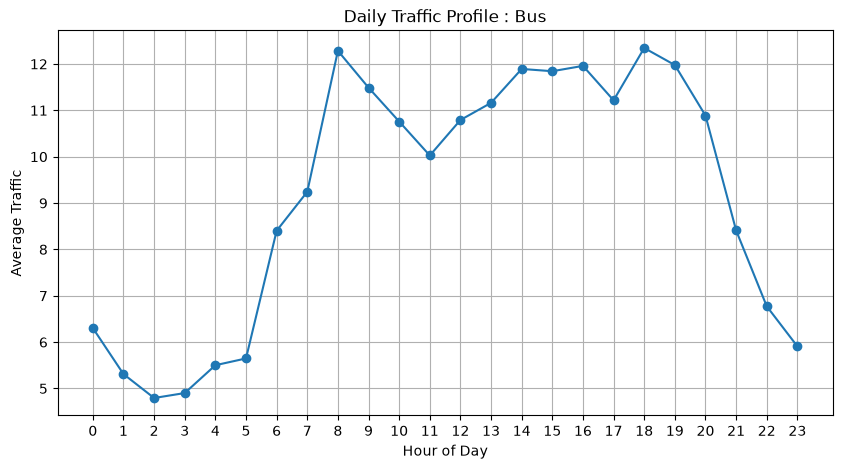

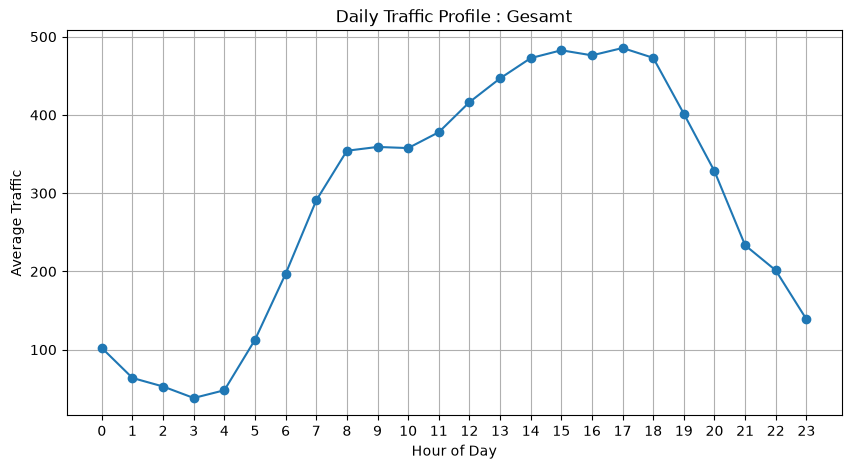

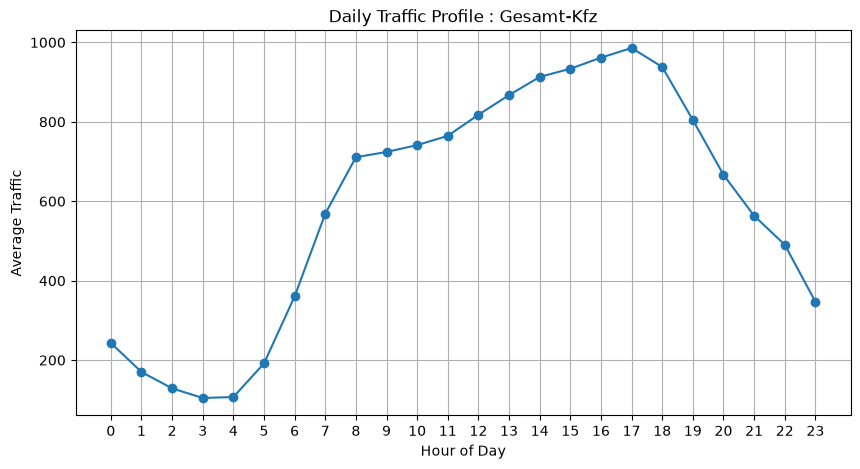

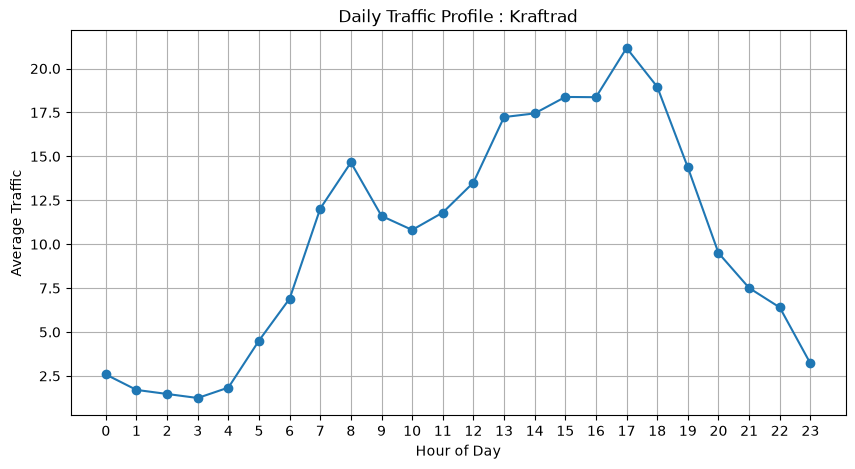

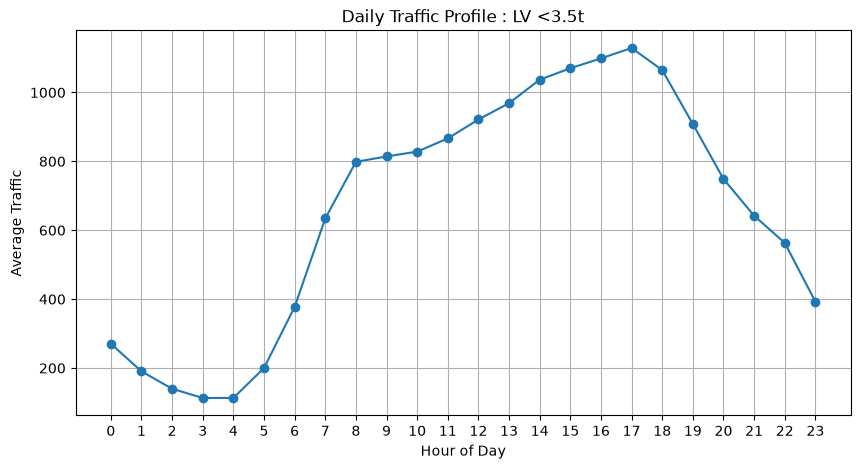

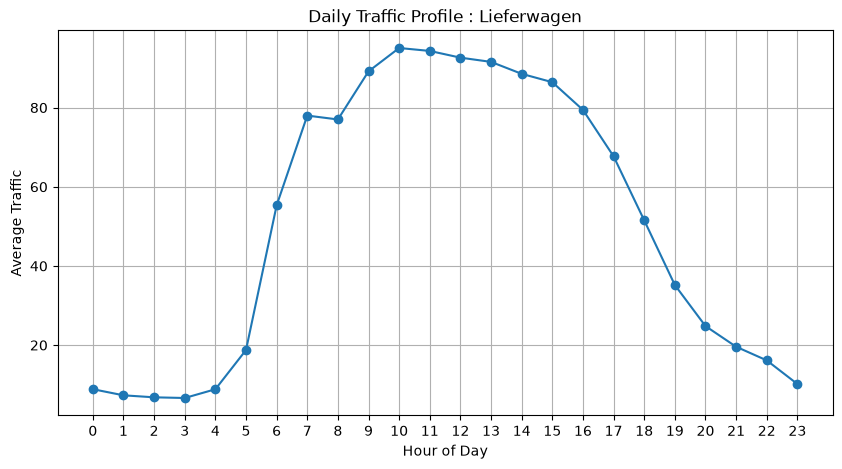

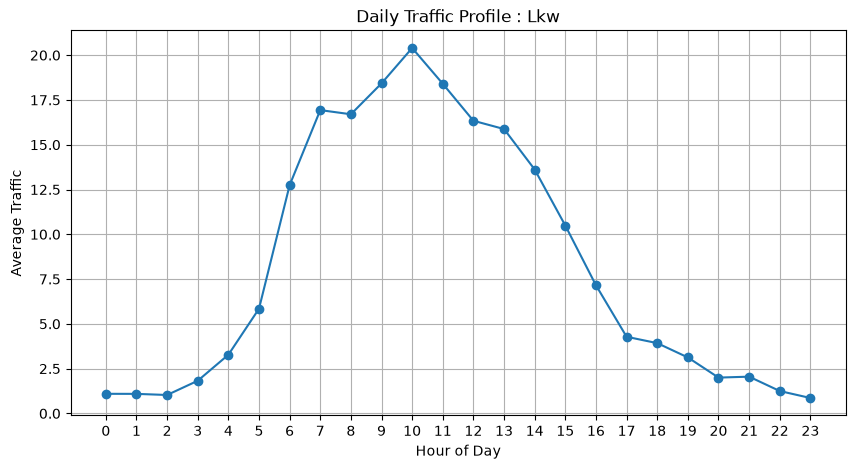

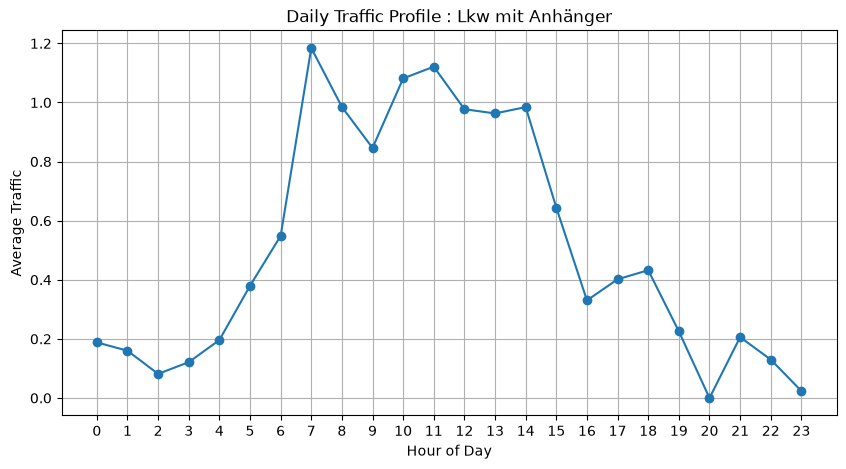

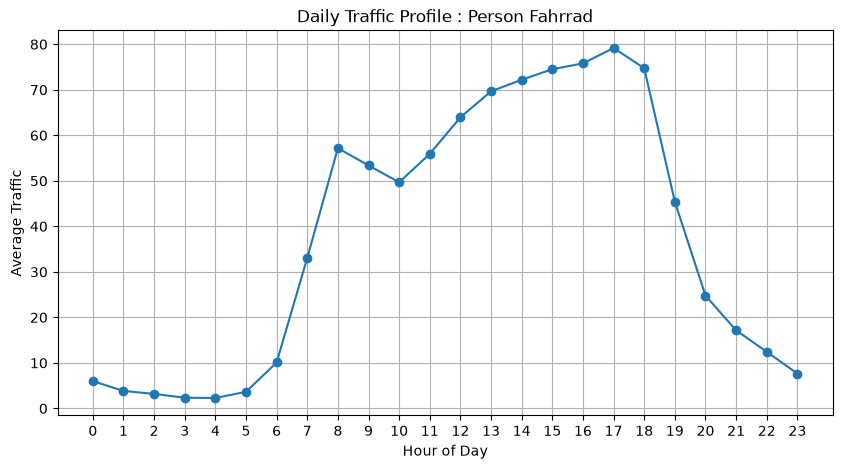

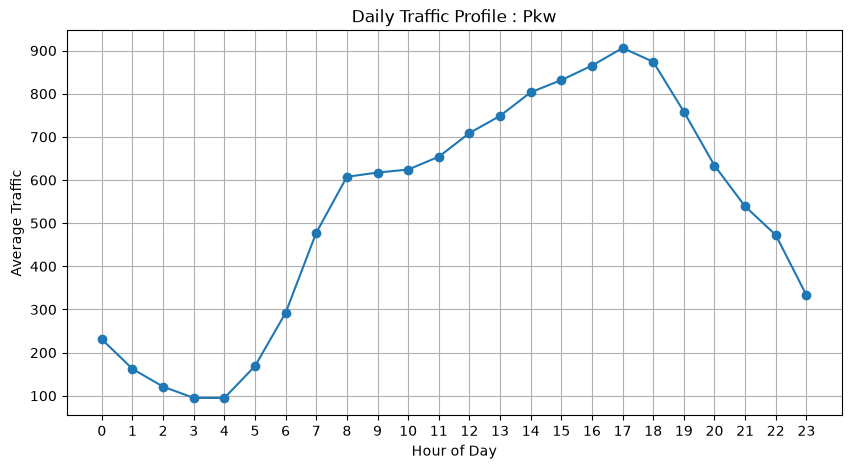

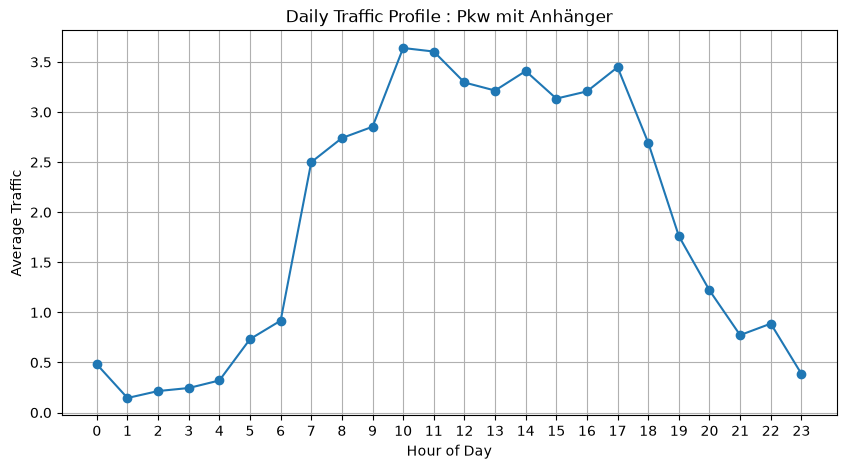

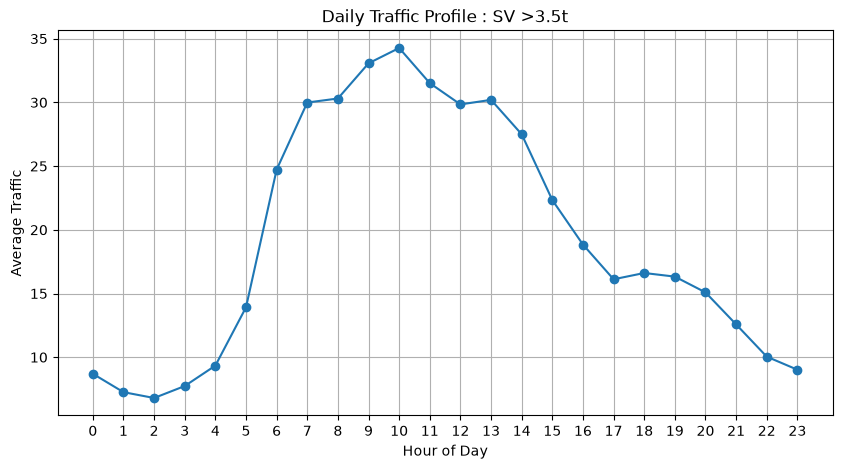

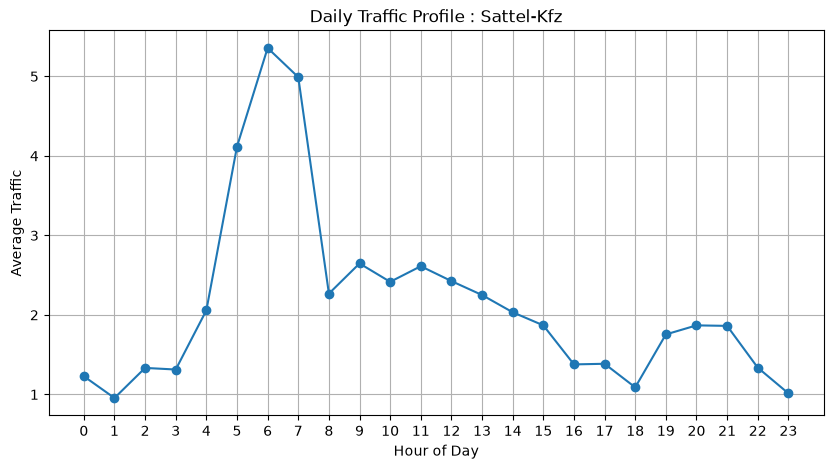

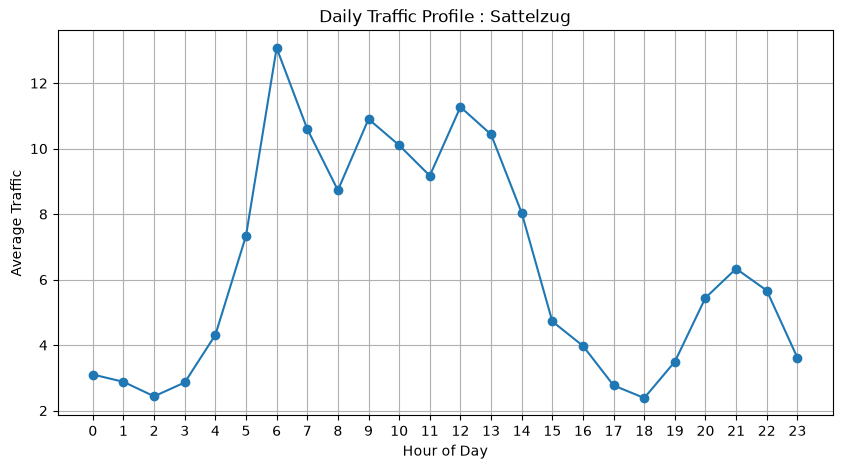

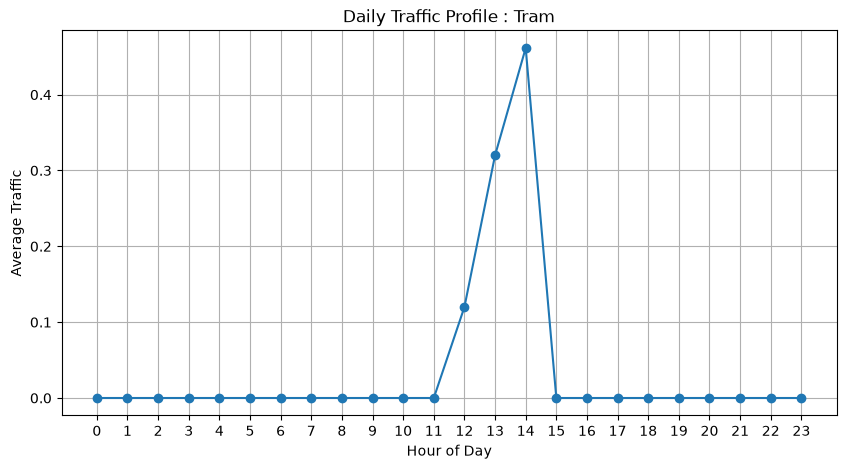

In [5]:
categories = hourly_profile["vehicle_category"].unique()

for category in categories:

    temp = hourly_profile[
        hourly_profile["vehicle_category"]==category
    ]

    plt.figure(figsize=(10,5))

    plt.plot(

        temp["hour"],

        temp["total_traffic"],

        marker="o"

    )

    plt.title(f"Daily Traffic Profile : {category}")

    plt.xlabel("Hour of Day")

    plt.ylabel("Average Traffic")

    plt.xticks(range(24))

    plt.grid()

    plt.show()

In [6]:
#peak hour detection
peak_hours = (

    hourly_profile

    .loc[

        hourly_profile

        .groupby("vehicle_category")

        ["total_traffic"]

        .idxmax()

    ]

)

peak_hours

,vehicle_category,hour,total_traffic
18,Bus,18.0,12.344051
41,Gesamt,17.0,485.611842
65,Gesamt-Kfz,17.0,985.887172
89,Kraftrad,17.0,21.169014
113,LV <3.5t,17.0,1129.058000
130,Lieferwagen,10.0,95.071795
154,Lkw,10.0,20.400438
175,Lkw mit Anhänger,7.0,1.184397
209,Person Fahrrad,17.0,79.178808
233,Pkw,17.0,906.032659


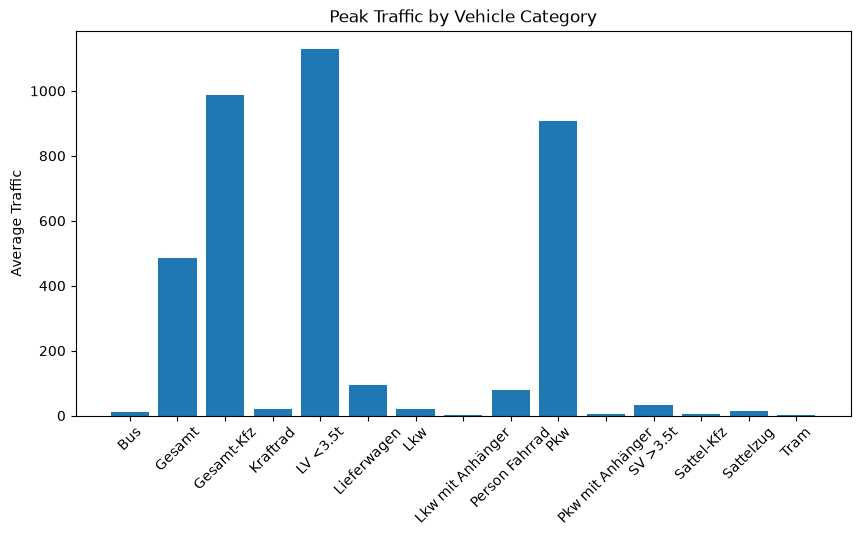

In [7]:
plt.figure(figsize=(10,5))

plt.bar(

    peak_hours["vehicle_category"],

    peak_hours["total_traffic"]

)

plt.title("Peak Traffic by Vehicle Category")

plt.ylabel("Average Traffic")

plt.xticks(rotation=45)

plt.show()

In [8]:
def traffic_period(hour):

    if 6 <= hour < 10:

        return "Morning Peak"

    elif 10 <= hour < 15:

        return "Midday"

    elif 15 <= hour < 19:

        return "Evening Peak"

    else:

        return "Off Peak"

In [9]:
df["traffic_period"] = df["hour"].apply(traffic_period)

df.head()

,week,measurement_site,latitude,longitude,vehicle_category,source_file,time,direction_1,direction_2,direction_3,direction_4,direction_5,direction_6,direction_7,direction_8,direction_9,direction_10,direction_11,direction_12,direction_13,direction_14,direction_15,direction_16,direction_17,direction_18,direction_19,direction_20,direction_21,direction_22,direction_23,direction_24,direction_25,direction_26,direction_27,direction_28,total_traffic,hour,minute,peak_period,traffic_period
0,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:00:00,5.0,43.0,9.0,17.0,0.0,0.0,74.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,52.0,0.0,43.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,274.0,0.0,0.0,Off Peak,Off Peak
1,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:15:00,4.0,31.0,15.0,14.0,0.0,0.0,64.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,46.0,0.0,31.0,0.0,0.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,238.0,0.0,15.0,Off Peak,Off Peak
2,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:30:00,5.0,35.0,7.0,23.0,0.0,0.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,42.0,0.0,35.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,252.0,0.0,30.0,Off Peak,Off Peak
3,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,00:45:00,4.0,36.0,4.0,15.0,0.0,0.0,59.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,40.0,0.0,36.0,0.0,0.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,217.0,0.0,45.0,Off Peak,Off Peak
4,DZwEI 30.09-07.10,Friedberger Tor,NaN,NaN,Gesamt-Kfz,2024-09-30_to_2024-10-07_UI_202403B0924.xlsx,01:00:00,6.0,15.0,7.0,15.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,22.0,0.0,15.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.0,1.0,0.0,Off Peak,Off Peak


In [10]:
period = (

    df.groupby(

        [

            "vehicle_category",

            "traffic_period"

        ]

    )["total_traffic"]

    .mean()

    .reset_index()

)

period

,vehicle_category,traffic_period,total_traffic
0,Bus,Evening Peak,11.845258
1,Bus,Midday,10.922095
2,Bus,Morning Peak,10.360669
3,Bus,Off Peak,13.926084
4,Gesamt,Evening Peak,479.430442
5,Gesamt,Midday,414.025707
6,Gesamt,Morning Peak,304.822526
7,Gesamt,Off Peak,168.492123
8,Gesamt-Kfz,Evening Peak,954.691600
9,Gesamt-Kfz,Midday,820.666868


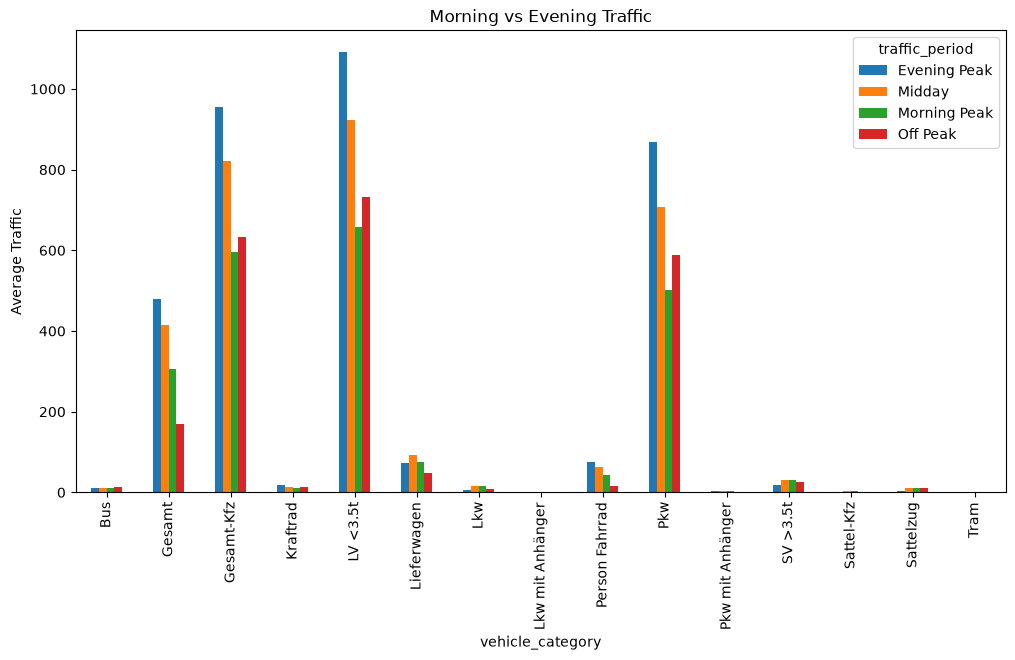

In [11]:
pivot = period.pivot(

    index="vehicle_category",

    columns="traffic_period",

    values="total_traffic"

)

pivot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.ylabel("Average Traffic")

plt.title("Morning vs Evening Traffic")

plt.show()

In [12]:
top = (

    df.groupby(

        [

            "vehicle_category",

            "hour"

        ]

    )["total_traffic"]

    .mean()

    .sort_values(

        ascending=False

    )

    .head(10)

)

top

vehicle_category  hour
LV <3.5t          17.0    1129.058000
                  16.0    1098.898000
                  15.0    1070.211155
                  18.0    1065.035644
                  14.0    1037.069583
Gesamt-Kfz        17.0     985.887172
LV <3.5t          13.0     968.906067
Gesamt-Kfz        16.0     961.588598
                  18.0     938.123077
                  15.0     933.677761
Name: total_traffic, dtype: float64

In [13]:
heat = pd.pivot_table(

    df,

    values="total_traffic",

    index="vehicle_category",

    columns="hour",

    aggfunc="mean"

)

heat

hour,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0
vehicle_category,,,,,,,,,,,,,,,,,,,,,,,,
Bus,6.303738,5.310924,4.795000,4.901786,5.501992,5.648305,8.402730,9.243333,12.283737,11.488818,10.758170,10.025641,10.790769,11.160883,11.892157,11.843137,11.958333,11.215488,12.344051,11.976027,10.886364,8.409449,6.772727,5.908772
Gesamt,102.168142,63.833333,52.923077,38.237113,48.145631,112.681416,196.992248,290.832215,354.278146,359.133758,357.692308,377.974522,416.371795,446.762821,472.686275,482.707006,476.210526,485.611842,473.000000,401.500000,328.103704,233.459854,201.350746,138.969231
Gesamt-Kfz,243.096667,170.126263,128.907965,104.634545,107.094474,191.727273,360.441368,568.754250,710.953704,724.077039,741.390318,764.696562,817.799100,867.371212,912.990909,933.677761,961.588598,985.887172,938.123077,804.634526,666.621664,563.381703,490.546311,347.077287
Kraftrad,2.583784,1.705479,1.473684,1.244755,1.837662,4.512438,6.899582,12.030211,14.653396,11.607889,10.811765,11.801282,13.510204,17.236402,17.446029,18.382294,18.368000,21.169014,18.960417,14.369193,9.498681,7.507886,6.400000,3.212838
LV <3.5t,270.482618,190.533195,139.904459,113.083700,113.310195,199.995745,377.507071,634.309237,798.583166,814.211045,828.294118,866.488235,921.524462,968.906067,1037.069583,1070.211155,1098.898000,1129.058000,1065.035644,908.248509,748.855446,642.155689,563.349901,392.712598
Lieferwagen,8.862464,7.314024,6.809375,6.636964,8.847025,18.753986,55.303774,77.996454,77.013605,89.168096,95.071795,94.327150,92.630435,91.559865,88.541455,86.429795,79.427305,67.699634,51.519924,35.177914,24.806818,19.589499,16.140260,10.170732
Lkw,1.094891,1.091549,1.028777,1.823529,3.275701,5.846154,12.741848,16.932886,16.700637,18.425806,20.400438,18.401766,16.337838,15.875566,13.615960,10.486631,7.154799,4.279070,3.924370,3.125581,2.000000,2.052326,1.250000,0.861111
Lkw mit Anhänger,0.188119,0.160000,0.081633,0.121212,0.196078,0.379630,0.548387,1.184397,0.984848,0.846154,1.081481,1.121212,0.977273,0.962963,0.984375,0.644068,0.330189,0.401786,0.432432,0.225490,0.000000,0.205882,0.130000,0.023669
Person Fahrrad,6.000000,3.840000,3.187500,2.347826,2.288889,3.646154,10.093023,33.093525,57.173333,53.375000,49.679739,55.929936,63.947368,69.664557,72.203822,74.512658,75.790850,79.178808,74.740000,45.380952,24.784173,17.157895,12.436170,7.653061


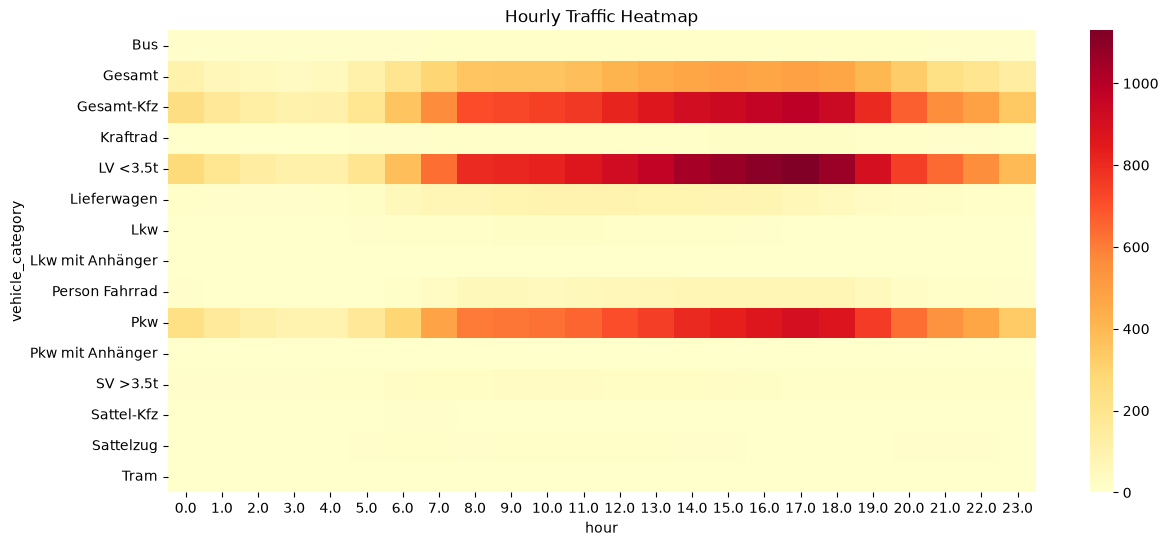

In [14]:
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(

    heat,

    cmap="YlOrRd",

    annot=False

)

plt.title("Hourly Traffic Heatmap")

plt.show()

In [15]:
summary = (

    peak_hours

    [["vehicle_category","hour","total_traffic"]]

    .rename(

        columns={

            "hour":"Peak Hour",

            "total_traffic":"Average Traffic"

        }

    )

)

summary

,vehicle_category,Peak Hour,Average Traffic
18,Bus,18.0,12.344051
41,Gesamt,17.0,485.611842
65,Gesamt-Kfz,17.0,985.887172
89,Kraftrad,17.0,21.169014
113,LV <3.5t,17.0,1129.058000
130,Lieferwagen,10.0,95.071795
154,Lkw,10.0,20.400438
175,Lkw mit Anhänger,7.0,1.184397
209,Person Fahrrad,17.0,79.178808
233,Pkw,17.0,906.032659


In [16]:
print("="*70)

print("TASK 1 SUMMARY")

print("="*70)

for _,row in summary.iterrows():

    print(

        f"{row['vehicle_category']} "

        f"shows the highest traffic around "

        f"{int(row['Peak Hour'])}:00 "

        f"with an average of "

        f"{round(row['Average Traffic'],2)} vehicles."

    )

TASK 1 SUMMARY
Bus shows the highest traffic around 18:00 with an average of 12.34 vehicles.
Gesamt shows the highest traffic around 17:00 with an average of 485.61 vehicles.
Gesamt-Kfz shows the highest traffic around 17:00 with an average of 985.89 vehicles.
Kraftrad shows the highest traffic around 17:00 with an average of 21.17 vehicles.
LV <3.5t shows the highest traffic around 17:00 with an average of 1129.06 vehicles.
Lieferwagen shows the highest traffic around 10:00 with an average of 95.07 vehicles.
Lkw shows the highest traffic around 10:00 with an average of 20.4 vehicles.
Lkw mit Anhänger shows the highest traffic around 7:00 with an average of 1.18 vehicles.
Person Fahrrad shows the highest traffic around 17:00 with an average of 79.18 vehicles.
Pkw shows the highest traffic around 17:00 with an average of 906.03 vehicles.
Pkw mit Anhänger shows the highest traffic around 10:00 with an average of 3.64 vehicles.
SV >3.5t shows the highest traffic around 10:00 with an avera

In [17]:
OUTPUT = PROJECT_DIR/"reports"

OUTPUT.mkdir(exist_ok=True)

summary.to_csv(

    OUTPUT/"task1_peak_hours.csv",

    index=False

)

print("Results saved successfully!")

Results saved successfully!
